# Predictive Modeling of Iris Flower Species Using ANN

In [7]:
import sys
!{sys.executable} -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [1]:
# Step 1 : Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Step 2 : Load dataset

iris = load_iris()

X = iris.data
y = iris.target

# Create dataframe
df = pd.DataFrame(X, columns=iris.feature_names)

# Add target column
df['Target'] = y

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Step 3 : Preprocessing

# Check null values
print(df.isnull().sum())

# Check duplicate values
print(df.duplicated().sum())

# Dataset shape
print(df.shape)

# Dataset info
print(df.info())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64
1
(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [4]:
# Step 4 : Separate input and output

X = df.drop('Target', axis=1)
y = df['Target']


In [5]:

# Step 5 : Label Encoding

le = LabelEncoder()

y = le.fit_transform(y)

# One-hot encoding
y_encoded = to_categorical(y)

print(y_encoded[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [6]:
# Step 6 : Normalize features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [7]:
# Step 7 : Train-test split

X_train, X_test, y_train, y_test = train_test_split(
X_scaled,
y_encoded,
test_size=0.2,
random_state=42

)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [8]:
# Step 8 : Build the model

model = Sequential()

# Hidden Layer 1
model.add(Dense(10, input_shape=(4,), activation='relu'))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(3, activation='softmax'))

In [9]:
# Step 9 : Compile the model

model. compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']

)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              88 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Step 10 : Train the model

history = model.fit(
X_train,
y_train,
epochs=50,
batch_size=8,
validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.0729 - loss: 1.0709 - val_accuracy: 0.3333 - val_loss: 1.0079
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1667 - loss: 1.0261 - val_accuracy: 0.3750 - val_loss: 0.9738
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3646 - loss: 0.9908 - val_accuracy: 0.6250 - val_loss: 0.9391
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6146 - loss: 0.9570 - val_accuracy: 0.8333 - val_loss: 0.9098
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6667 - loss: 0.9255 - val_accuracy: 0.8333 - val_loss: 0.8826
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6875 - loss: 0.8948 - val_accuracy: 0.8750 - val_loss: 0.8533
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7292 - loss: 0.8623 - val_accuracy: 0.8750 - val_loss: 0.8262
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7396 - loss: 0.8296 - val_accuracy: 0.8750 - val_loss

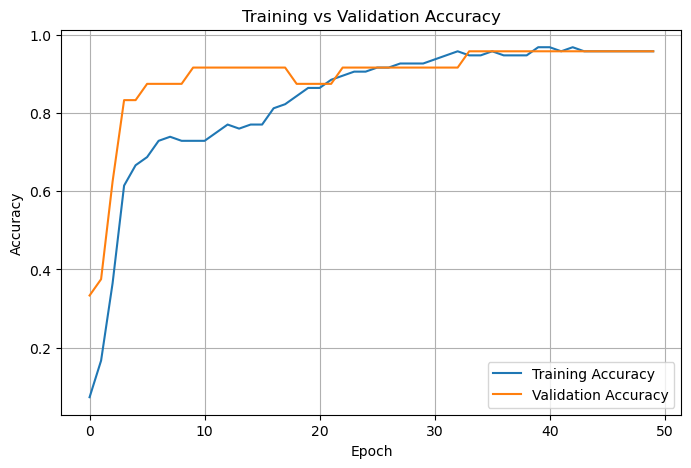

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

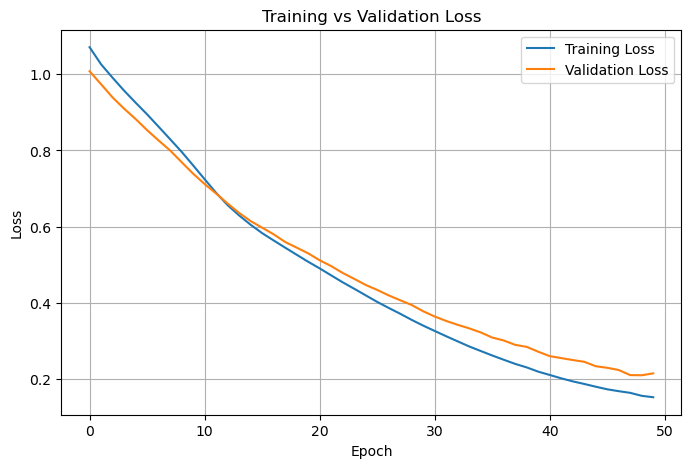

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
# Step 11 : Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 1.0000 - loss: 0.1249
Loss : 0.12485429644584656
Accuracy : 1.0


In [16]:
# Step 12 : Prediction

y_pred = model.predict(X_test)

# Convert predicted values
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert actual values
y_test_classes = np.argmax(y_test, axis=1)

print("Predicted Values :")
print(y_pred_classes[:10])

print("Actual Values :")
print(y_test_classes[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted Values :
[1 0 2 1 1 0 1 2 1 1]
Actual Values :
[1 0 2 1 1 0 1 2 1 1]


In [17]:
# Step 13 : Accuracy score

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test_classes, y_pred_classes)

print("Accuracy Score :", acc)

Accuracy Score : 1.0


In [18]:
# Step 14 : Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



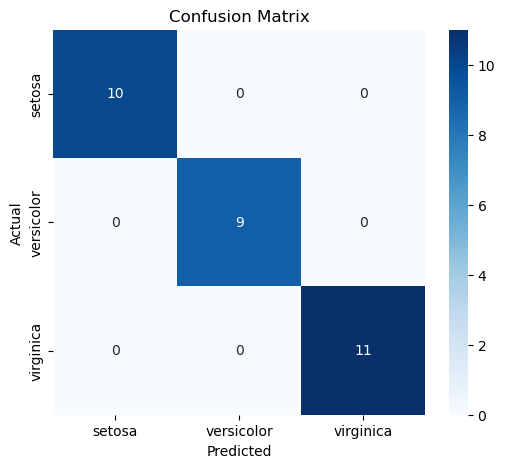

In [19]:
cm = confusion_matrix(y_pred_classes, y_test_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [20]:
model.save("iris_ann_model.keras")

print("Model Saved Successfully.")

Model Saved Successfully.


In [21]:
joblib.dump(scaler, "iris_scaler.pkl")

print("Scaler Saved Successfully.")

Scaler Saved Successfully.


In [22]:
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)

predicted_class = np.argmax(prediction)

predicted_species = iris.target_names[predicted_class]

print("Predicted Flower Species :", predicted_species)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Flower Species : setosa


In [23]:
samples = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.2, 2.9, 4.3, 1.3],
    [6.8, 3.2, 5.9, 2.3]
])

samples_scaled = scaler.transform(samples)

predictions = model.predict(samples_scaled)

print("\nPredictions:")

for sample, pred in zip(samples, predictions):
    species = iris.target_names[np.argmax(pred)]
    print(sample, " ---> ", species)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Predictions:
[5.1 3.5 1.4 0.2]  --->  setosa
[6.2 2.9 4.3 1.3]  --->  versicolor
[6.8 3.2 5.9 2.3]  --->  virginica


# Conclusion

The Iris Flower dataset was successfully analyzed and classified using an Artificial Neural Network (ANN) model. After preprocessing the data and training the network, the model was able to accurately distinguish among the three iris species—Setosa, Versicolor, and Virginica—based on their sepal and petal measurements. The results demonstrate that ANN is an effective deep learning technique for multi-class classification problems. The high accuracy achieved indicates that the model has learned the underlying patterns in the dataset and can generalize well to unseen data. Overall, this project highlights the potential of neural networks in solving classification tasks and provides a strong foundation for applying deep learning techniques to more complex real-world datasets.